In [45]:
from extract_frame_data import load_full_data
from statsmodels.stats.proportion import proportions_ztest
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3
from matplotlib_venn import venn3, venn3_circles
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm

### Data manipulation 

Import data from colour phi task 

In [4]:
data_colour = pd.read_csv("Colourphi.csv")
report_coded_1 = pd.read_csv("Batch 1-8_coding_review_corrected.csv")
report_coded_2 = pd.read_csv("Batch 9-16_coding_review_corrected.csv")
report_coded_2.index = range(200, 400)
report_coded = pd.concat([report_coded_1, report_coded_2], axis = 0)
data_colour = pd.concat([data_colour, report_coded[['final_movement', 'final_colour_change', 'final_change_type', 'final_valid']]], axis = 1)
data_colour = data_colour.rename(columns={ "final_movement": "movement",
                            "final_colour_change": "colour_change",
                            "final_change_type": "change_type",
                            "final_valid": "valid"})

Import data from phi motion task 

In [6]:
data_phi = pd.read_csv("data_raw.csv")
data_phi["condition"] = "phi_2frames"

phi_coded = pd.read_csv("phi_codes.csv")
data_phi = pd.concat([data_phi, phi_coded[["movement","valid"]]], axis = 1)

Combine & Create columns for plotting 

In [8]:
data = pd.concat([data_colour, data_phi], ignore_index=True)
data.loc[:, "one_shape"] = data["shape_number"] == "1"
data.loc[:, "4_frames"] = data["matched_stimuli"].isin(["4frames_gradual", "4frames_discrete", "motion_4frames", "discrete_4frames"])
data.loc[:, "discrete_report"] = data["change_type"] == "Discrete"
data.loc[:, "discrete_match"] = data["matched_stimuli"] == "4frames_discrete"
data.to_csv("full_data.csv")

Rejection criteria: frame durations are not empty & valid report of geometric shapes

In [10]:
# Check frame durations
print(sum(data.frame_1_duration_ms.isna() == True))
print(sum(data.frame_2_duration_ms.isna() == True))
print(sum(data.frame_3_duration_ms.isna() == True))
print(sum(data.frame_4_duration_ms.isna() == True))
print(sum(data.valid.isna() == True))

1
1
2
2
0


In [11]:
data = data.dropna(subset = ["frame_1_duration_ms",
                     "frame_2_duration_ms",
                     "frame_3_duration_ms",
                     "frame_4_duration_ms"])
data = data[data["valid"] == True]
data.shape

(593, 22)

Separate conditions and count trials 

In [13]:
illusion_condition = data.query("condition == 'illusion_2frames'")
illusion_trials = len(illusion_condition)
baseline_condition = data.query("condition == 'baseline_2frames'")
baseline_trials = len(baseline_condition)
phi_condition = data.query("condition == 'phi_2frames'")
phi_trials = len(phi_condition)

print(f"illusion_trials: {illusion_trials}")
print(f"baseline_trials: {baseline_trials}")
print(f"phi_trials: {phi_trials}")

illusion_trials: 200
baseline_trials: 195
phi_trials: 198


### Pre-registered analyses

#### Colour phi task 

H1 [motion reports]: compare proportions of motion codes 

In [17]:
illusion_motion = len(illusion_condition.query("movement == True"))
baseline_motion = len(baseline_condition.query("movement == True"))

successes = np.array([illusion_motion, baseline_motion])
trials = np.array([illusion_trials, baseline_trials])

z_stat, p_value = proportions_ztest(count = successes, 
                                    nobs = trials,
                                   alternative = "two-sided")

print(f"Z-statistic: {z_stat:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"illusion_proportions: {illusion_motion / illusion_trials:.3f}")
print(f"baseline_proportions: {baseline_motion / baseline_trials:.3f}")
print(f"illusion_motion: {illusion_motion}")
print(f"baseline_motion: {baseline_motion}")

Z-statistic: 3.951
P-value: 0.000
illusion_proportions: 0.170
baseline_proportions: 0.046
illusion_motion: 34
baseline_motion: 9


H2 [colour change reports]: compare proportions of colour change codes 

In [19]:
illusion_change = illusion_condition.query("colour_change == True")
illusion_change_trials = len(illusion_change)
baseline_change = baseline_condition.query("colour_change == True")
baseline_change_trials = len(baseline_change)

successes = np.array([illusion_change_trials, baseline_change_trials])
trials = np.array([illusion_trials, baseline_trials])

z_stat, p_value = proportions_ztest(count = successes, 
                                    nobs = trials,
                                   alternative = "two-sided")

print(f"Z-statistic: {z_stat:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"illusion_proportions: {illusion_change_trials / illusion_trials:.3f}")
print(f"baseline_proportions: {baseline_change_trials / baseline_trials:.3f}")

Z-statistic: 2.636
P-value: 0.008
illusion_proportions: 0.035
baseline_proportions: 0.000


H3 [discrete colour change reports]: compare proportion of dicrete codes, out of colour change responses only 

In [21]:
illusion_discrete = len(illusion_change.query("change_type == 'Discrete'"))
baseline_discrete = len(baseline_change.query("change_type == 'Discrete'"))

successes = np.array([illusion_discrete, baseline_discrete])
trials = np.array([illusion_change_trials, baseline_change_trials])

print(f"Z-statistic: {z_stat:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"illusion_discrete: {illusion_discrete}")
print(f"illusion_change: {illusion_change_trials}")
print(f"baseline_discrete: {baseline_discrete}")
print(f"baseline_change: {baseline_change_trials}")

Z-statistic: 2.636
P-value: 0.008
illusion_discrete: 5
illusion_change: 7
baseline_discrete: 0
baseline_change: 0


H4 [shape number perception]: compare proportion of single shape reports out of those reporting one or two 

In [23]:
illusion_valid = illusion_condition.query("shape_number == '1' or shape_number == '2'")
illusion_valid_trials = len(illusion_valid)
illusion_one_shape = len(illusion_valid.query("shape_number == '1'"))

baseline_valid = baseline_condition.query("shape_number == '1' or shape_number == '2'")
baseline_valid_trials = len(baseline_valid)
baseline_one_shape = len(baseline_valid.query("shape_number == '1'"))

successes = np.array([illusion_one_shape, baseline_one_shape])
trials = np.array([illusion_valid_trials, baseline_valid_trials])

z_stat, p_value = proportions_ztest(count = successes, 
                                    nobs = trials,
                                   alternative = "two-sided")

print(f"Z-statistic: {z_stat:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"illusion_proportions: {illusion_one_shape / illusion_valid_trials:.3f}")
print(f"baseline_proportions: {baseline_one_shape / baseline_valid_trials:.3f}")

Z-statistic: 0.145
P-value: 0.885
illusion_proportions: 0.062
baseline_proportions: 0.058


H5 [frame sequence type]: compare proportion of choosing continous frame sequences

In [25]:
illusion_matched_motion = illusion_condition.query("matched_stimuli == '4frames_gradual' or matched_stimuli == '4frames_discrete'")
illusion_matched_motion_trials = len(illusion_matched_motion)
baseline_matched_motion = baseline_condition.query("matched_stimuli == '4frames_gradual' or matched_stimuli == '4frames_discrete'")
baseline_matched_motion_trials = len(baseline_matched_motion)

successes = np.array([illusion_matched_motion_trials, baseline_matched_motion_trials])
trials = np.array([illusion_trials, baseline_trials])

z_stat, p_value = proportions_ztest(count = successes, 
                                    nobs = trials,
                                   alternative = "two-sided")

print(f"Z-statistic: {z_stat:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"illusion_proportions: {illusion_matched_motion_trials / illusion_trials:.3f}")
print(f"baseline_proportions: {baseline_matched_motion_trials / baseline_trials:.3f}")

Z-statistic: 3.482
P-value: 0.000
illusion_proportions: 0.125
baseline_proportions: 0.031


H6 [frame sequence colour change]: compare proportions of choosing dicrete change frame sequence, among those choosing continous ones

In [27]:
illusion_matched_discrete = len(illusion_matched_motion.query("matched_stimuli == '4frames_discrete'"))
baseline_matched_discrete = len(baseline_matched_motion.query("matched_stimuli == '4frames_discrete'"))

successes = np.array([illusion_matched_discrete, baseline_matched_discrete])
trials = np.array([illusion_matched_motion_trials, baseline_matched_motion_trials])

z_stat, p_value = proportions_ztest(count = successes, 
                                    nobs = trials,
                                   alternative = "two-sided")

print(f"Z-statistic: {z_stat:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"illusion_proportions: {illusion_matched_discrete / illusion_matched_motion_trials:.3f}")
print(f"baseline_proportions: {baseline_matched_discrete / baseline_matched_motion_trials:.3f}")
print(f"illusion_matched_discrete: {illusion_matched_discrete}")
print(f"illusion_matched_change: {illusion_matched_motion_trials}")
print(f"baseline_matched_discrete: {baseline_matched_discrete}")
print(f"baseline_change: {baseline_matched_motion_trials}")

Z-statistic: -0.743
P-value: 0.457
illusion_proportions: 0.680
baseline_proportions: 0.833
illusion_matched_discrete: 17
illusion_matched_change: 25
baseline_matched_discrete: 5
baseline_change: 6


#### Phi motion task 

H7 [motion report][with phi condition]

In [30]:
phi_motion = len(phi_condition.query("movement == True"))

successes = np.array([illusion_motion, phi_motion])
trials = np.array([illusion_trials, phi_trials])

z_stat, p_value = proportions_ztest(count = successes, 
                                    nobs = trials,
                                   alternative = "two-sided")

print(f"Z-statistic: {z_stat:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"illusion_proportions: {illusion_motion / illusion_trials:.3f}")
print(f"phi_proportions: {phi_motion / phi_trials:.3f}")

Z-statistic: -4.167
P-value: 0.000
illusion_proportions: 0.170
phi_proportions: 0.354


In [31]:
illusion_motion

34

H8 [shape number perception] [with phi condition]

In [33]:
phi_valid = phi_condition.query("shape_number == '1' or shape_number == '2'")
phi_valid_trials = len(phi_valid)
phi_one_shape = len(phi_valid.query("shape_number == '1'"))


successes = np.array([illusion_one_shape, phi_one_shape])
trials = np.array([illusion_valid_trials, phi_valid_trials])

z_stat, p_value = proportions_ztest(count = successes, 
                                    nobs = trials,
                                   alternative = "two-sided")

print(f"Z-statistic: {z_stat:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"colour_proportions: {illusion_one_shape / illusion_valid_trials:.3f}")
print(f"phi_proportions: {phi_one_shape / phi_valid_trials:.3f}")

Z-statistic: -5.452
P-value: 0.000
colour_proportions: 0.062
phi_proportions: 0.281


H9 [frame sequence perception] [with phi condition]

In [35]:
phi_matched_motion = phi_condition.query("matched_stimuli == 'motion_4frames' or matched_stimuli == 'discrete_4frames'")
phi_matched_motion_trials = len(phi_matched_motion)


successes = np.array([illusion_matched_motion_trials, phi_matched_motion_trials])
trials = np.array([illusion_trials, phi_trials])

z_stat, p_value = proportions_ztest(count = successes, 
                                    nobs = trials,
                                   alternative = "two-sided")

print(f"Z-statistic: {z_stat:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"colour_proportions: {illusion_matched_motion_trials / illusion_trials:.3f}")
print(f"phi_proportions: {phi_matched_motion_trials / phi_trials:.3f}")

Z-statistic: -4.847
P-value: 0.000
colour_proportions: 0.125
phi_proportions: 0.328


### Plotting 

Bar plots showing proportion comparisons regarding motion, across all conditions

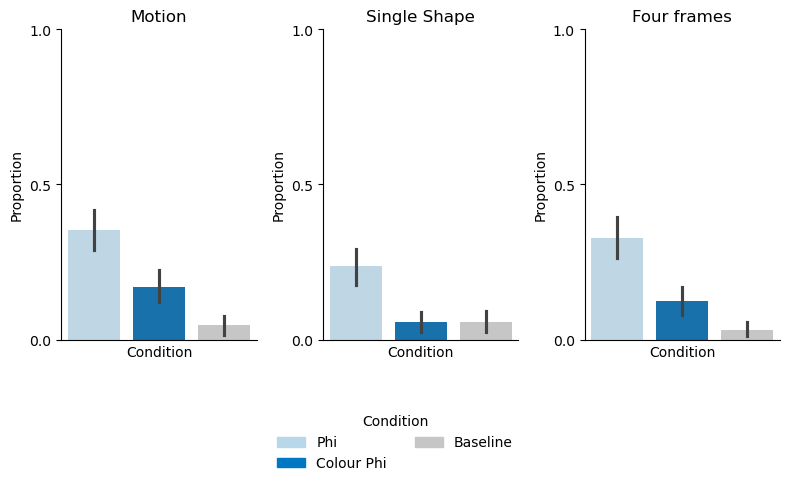

In [38]:
palette = {"phi_2frames": "#b9d7eb", "illusion_2frames": "#0077c2", "baseline_2frames": "#c6c6c6"}
condition_order = ["phi_2frames", "illusion_2frames", "baseline_2frames"]  

fig, axes = plt.subplots(1, 3, figsize=[8, 4])

metrics = [
    (data, "movement", "Motion"),
    (data, "one_shape", "Single Shape"),
    (data, "4_frames", "Four frames"),
]

for ax, (df, y, title) in zip(axes, metrics):
    sns.barplot(
        data=df, x="condition", hue="condition", y=y,
        errorbar=('ci', 95), palette=palette, ax=ax, legend=False,
        order=condition_order, hue_order=condition_order,
    )
    ax.set_xticks([])
    ax.set_ylabel("Proportion")
    ax.set_xlabel("Condition")
    ax.set_yticks([0, 0.5, 1])
    ax.set_title(title)
    sns.despine(ax=ax)

# Build legend handles manually from the palette, so colors are guaranteed correct
handles = [plt.Rectangle((0, 0), 1, 1, color=palette[cond]) for cond in palette]
labels = ["Phi", "Colour Phi", "Baseline"]  # match order of palette dict above

legend = fig.legend(handles, labels, title="Condition", loc="upper center",
                     bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])
fig.savefig("Figure_motion.png", dpi=300, bbox_inches="tight",
            bbox_extra_artists=[legend])
plt.show()

Bar plots showing proportion comparisons regarding colour change, across for colour phi task

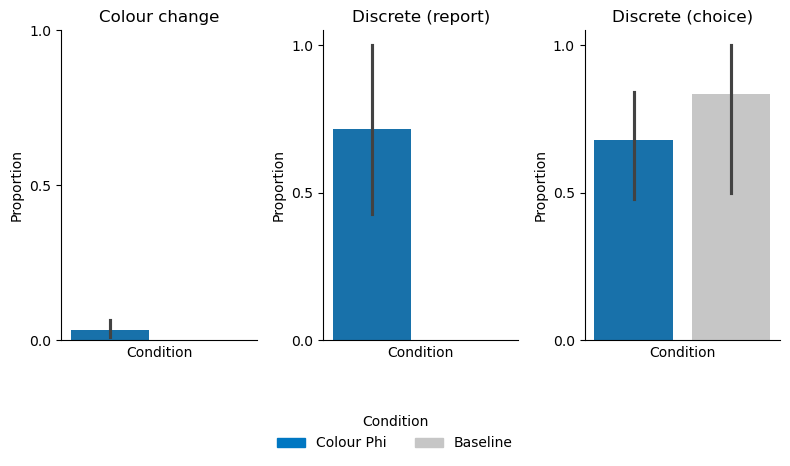

In [40]:
palette = {"illusion_2frames": "#0077c2", "baseline_2frames": "#c6c6c6"}
condition_order = ["illusion_2frames", "baseline_2frames"]  

fig, axes = plt.subplots(1, 3, figsize=[8, 4])

metrics = [
    (data, "colour_change", "Colour change"),
    (data.query("colour_change == True"), "discrete_report", "Discrete (report)"),
    (data.query("matched_stimuli == '4frames_gradual' or matched_stimuli == '4frames_discrete'"), "discrete_match", "Discrete (choice)"),
]

for ax, (df, y, title) in zip(axes, metrics):
    sns.barplot(
        data=df, x="condition", hue="condition", y=y,
        errorbar=('ci', 95), palette=palette, ax=ax, legend=False,
        order=condition_order, hue_order=condition_order,
    )
    ax.set_xticks([])
    ax.set_ylabel("Proportion")
    ax.set_xlabel("Condition")
    ax.set_yticks([0, 0.5, 1])
    ax.set_title(title)
    sns.despine(ax=ax)

# Build legend handles manually from the palette, so colors are guaranteed correct
handles = [plt.Rectangle((0, 0), 1, 1, color=palette[cond]) for cond in palette]
labels = ["Colour Phi", "Baseline"]  # match order of palette dict above

legend = fig.legend(handles, labels, title="Condition", loc="upper center",
                     bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])
fig.savefig("Figure_change.png", dpi=300, bbox_inches="tight",
            bbox_extra_artists=[legend])
plt.show()

Correlations between motion reports

In [42]:
label_sets_illusion = {
    col: set(illusion_condition.loc[data[col] == 1, 'subj_id'])
    for col in ['movement', 'one_shape', '4_frames']
}

label_sets_phi = {
    col: set(phi_condition.loc[data[col] == 1, 'subj_id'])
    for col in ['movement', 'one_shape', '4_frames']
}

set_A = label_sets_illusion['movement']
set_B = label_sets_illusion['one_shape']
set_C = label_sets_illusion['4_frames']
set_D = label_sets_phi['movement']
set_E = label_sets_phi['one_shape']
set_F = label_sets_phi['4_frames']

totals = {
    'illusion':  (len(set_A) + len(set_B) + len(set_C)),
    'phi': (len(set_D) + len(set_E) + len(set_F)),
}
biggest_total = max(totals.values())

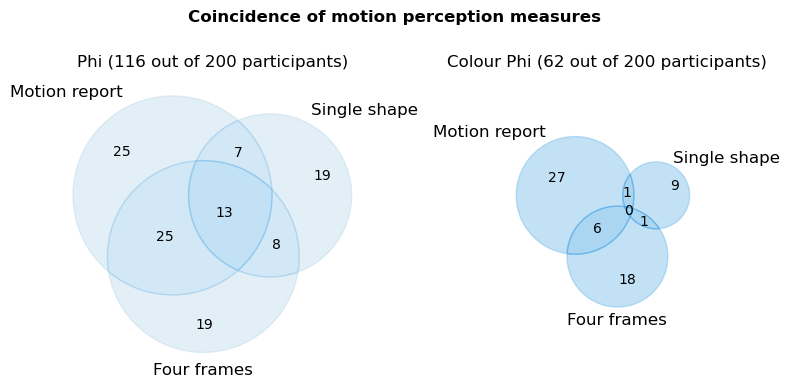

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (8, 4))

v1 = venn3(subsets = [set_D, set_E, set_F], set_labels = ('Motion report', 'Single shape', 'Four frames'), ax = ax1,
           layout_algorithm = DefaultLayoutAlgorithm(normalize_to = totals['phi']))
v1.get_patch_by_id('100').set_color('#b9d7eb')     # A only
v1.get_patch_by_id('010').set_color('#b9d7eb')   # B only
v1.get_patch_by_id('001').set_color('#b9d7eb')    # C only
v1.get_patch_by_id('110').set_color('#8fc6eb')  # A∩B
v1.get_patch_by_id('101').set_color('#8fc6eb')    # A∩C
v1.get_patch_by_id('011').set_color('#8fc6eb') # B∩C
v1.get_patch_by_id('111').set_color('#68b5e8')   # A∩B∩C

v2 = venn3(subsets = [set_A, set_B, set_C], set_labels = ('Motion report', 'Single shape', 'Four frames'), ax = ax2,
           layout_algorithm = DefaultLayoutAlgorithm(normalize_to = totals['illusion']))
v2.get_patch_by_id('100').set_color('#68b5e8')     # A only
v2.get_patch_by_id('010').set_color('#68b5e8')   # B only
v2.get_patch_by_id('001').set_color('#68b5e8')    # C only
v2.get_patch_by_id('110').set_color('#2d99e0')  # A∩B
v2.get_patch_by_id('101').set_color('#2d99e0')    # A∩C
v2.get_patch_by_id('011').set_color('#2d99e0') # B∩C
v2.get_patch_by_id('111').set_color('#2d99e0')   # A∩B∩C
 
ax1.set_title("Phi (116 out of 200 participants)", pad = 20)
ax2.set_title("Colour Phi (62 out of 200 participants)", pad = 20)
 
# venn3() already auto-fit ax1 to the LARGER diagram (assuming left has the
# bigger total) — grab that window and force ax2 to use the same one, so the
# smaller diagram actually renders smaller instead of stretching to fill.
xlim, ylim = ax1.get_xlim(), ax1.get_ylim()
for ax in (ax1, ax2):
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

fig.suptitle("Coincidence of motion perception measures", fontweight="bold")
 
plt.tight_layout()
fig.savefig("Figure_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

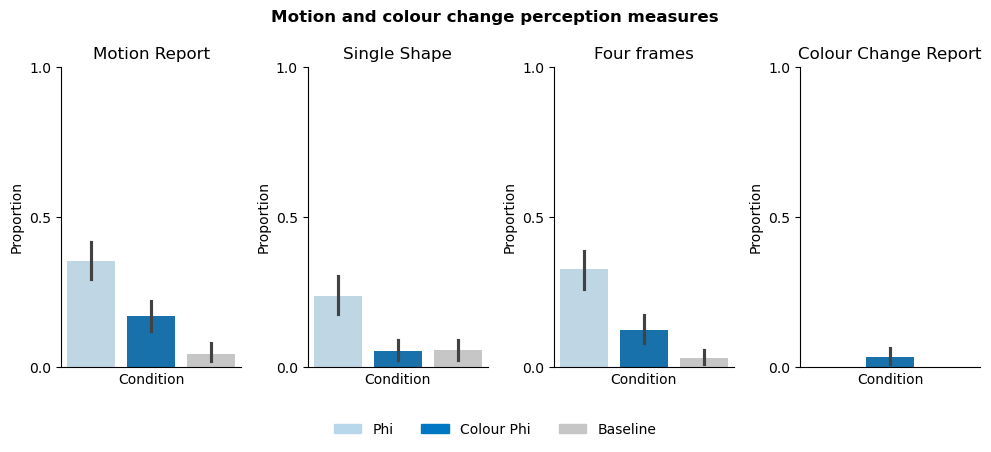

In [49]:
palette = {"phi_2frames": "#b9d7eb", "illusion_2frames": "#0077c2", "baseline_2frames": "#c6c6c6"}
condition_order = ["phi_2frames", "illusion_2frames", "baseline_2frames"]  

fig, axes = plt.subplots(1, 4, figsize=[10, 4])

metrics = [
    (data, "movement", "Motion Report"),
    (data, "one_shape", "Single Shape"),
    (data, "4_frames", "Four frames"),
    (data, "colour_change", "Colour Change Report"),
]

for ax, (df, y, title) in zip(axes, metrics):
    sns.barplot(
        data=df, x="condition", hue="condition", y=y,
        errorbar=('ci', 95), palette=palette, ax=ax, legend=False,
        order=condition_order, hue_order=condition_order,
    )
    ax.set_xticks([])
    ax.set_ylabel("Proportion")
    ax.set_xlabel("Condition")
    ax.set_yticks([0, 0.5, 1])
    ax.set_title(title)
    sns.despine(ax=ax)

# Build legend handles manually from the palette, so colors are guaranteed correct
handles = [plt.Rectangle((0, 0), 1, 1, color=palette[cond]) for cond in palette]
labels = ["Phi", "Colour Phi", "Baseline"]  # match order of palette dict above

legend = fig.legend(handles, labels, loc="upper center",
                     bbox_to_anchor=(0.5, -0.02), ncol = 3, frameon=False)

suptitle = fig.suptitle("Motion and colour change perception measures", fontweight="bold")

plt.tight_layout()
fig.savefig("Figure_combined.png", dpi=300, bbox_inches="tight",
            bbox_extra_artists = [legend, suptitle])
plt.show()

In [56]:
data.to_csv("Response_Data.csv")